# Create synthetic data to test tensorly decomposition


In [1]:
import os
import numpy as np
import nibabel as nib
from nilearn.plotting import plot_carpet, plot_stat_map
from nilearn.masking import compute_brain_mask
import matplotlib.pyplot as plt

/home/jeffrey/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
base_dir = os.path.expanduser(
    "~/Projects/Tensor_TE/bids/derivatives/sub-10317/func"
)

task = "doors"
run = "1"

# Load first echo to define shape
ref_img = nib.load(
    os.path.join(
        base_dir,
        f"sub-10317_task-{task}_run-{run}_echo-1_part-mag_desc-preproc_bold.nii.gz"
    )
)

data = ref_img.get_fdata()
first_vol = data[..., 0]

T = data.shape[3]

# Create 4 constant echoes
constant_imgs = []

for echo in range(1, 5):
    synthetic = np.repeat(first_vol[..., np.newaxis], T, axis=3)
    constant_imgs.append(synthetic)

# Save them
for echo, img_data in enumerate(constant_imgs, start=1):
    new_img = nib.Nifti1Image(img_data, ref_img.affine, ref_img.header)
    out_path = os.path.join(
        base_dir,
        f"synthetic_constant_echo-{echo}.nii.gz"
    )
    nib.save(new_img, out_path)

In [3]:
# Sanity Checks
print("original data shape:",data[0].shape)
print("diff of images:",np.sum(data[:,:,:,0]-data[:,:,:,100]))
print("Constant data shape:",constant_imgs[0].shape)
print("diff of images:",np.sum(constant_imgs[0][:,:,:,0]-constant_imgs[0][:,:,:,100]))

original data shape: (80, 51, 218)
diff of images: 4484843.51282521
Constant data shape: (80, 80, 51, 218)
diff of images: 0.0


# Add Unique Noise

In [4]:
noise_level = 0.5

for echo in range(1, 5):
    path = os.path.join(
        base_dir,
        f"synthetic_constant_echo-{echo}.nii.gz"
    )

    img = nib.load(path)
    data = img.get_fdata()

    noisy = data + noise_level * np.random.randn(*data.shape)

    new_img = nib.Nifti1Image(noisy, img.affine, img.header)
    nib.save(new_img, path)  # overwrite

In [5]:
from nilearn.image import math_img, index_img
print("original data shape:",data.shape)
print("diff of images:",np.sum(data[:,:,:,0]-data[:,:,:,100]))
print("Constant data shape:",new_img.shape)
img=nib.load(path)
data = img.get_fdata()
print("diff of images:",np.sum(data[:,:,:,0]-data[:,:,:,100]))


original data shape: (80, 80, 51, 218)
diff of images: 0.0
Constant data shape: (80, 80, 51, 218)
diff of images: 314.31804662563627


# Helper functions for synthetic components

Saved to /home/jeffrey/Projects/Tensor_TE/code/notebooks/notebooks/three_tensor_components.npz


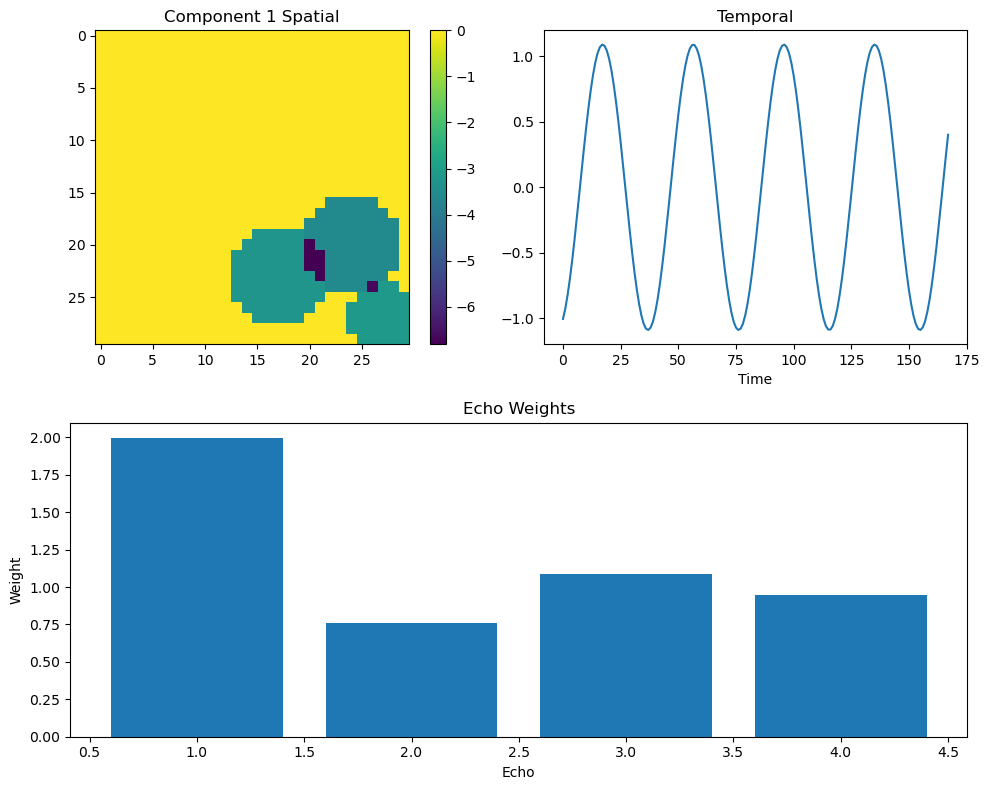

Saved figure: /home/jeffrey/Projects/Tensor_TE/code/notebooks/notebooks/component_1.png


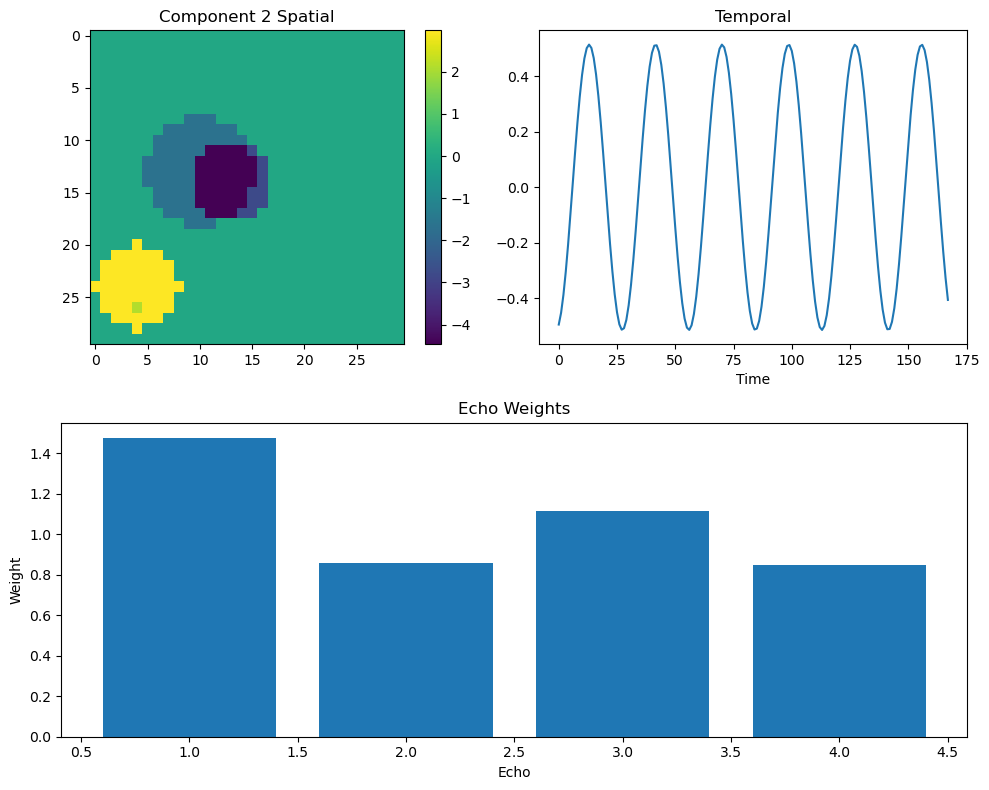

Saved figure: /home/jeffrey/Projects/Tensor_TE/code/notebooks/notebooks/component_2.png


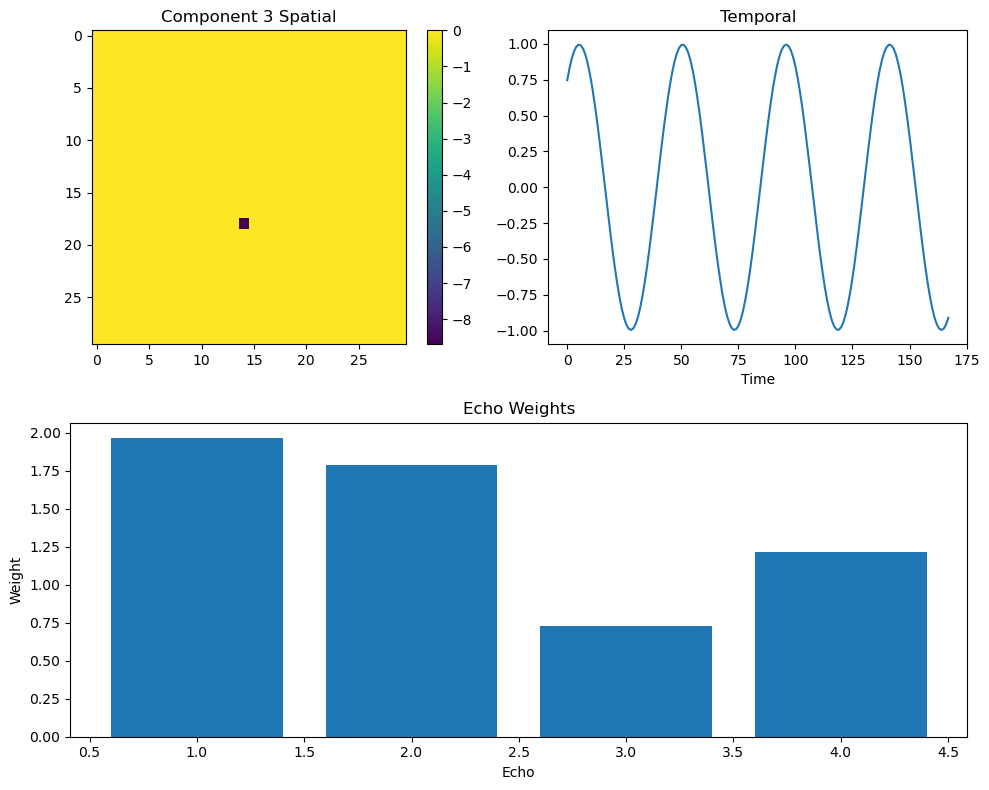

Saved figure: /home/jeffrey/Projects/Tensor_TE/code/notebooks/notebooks/component_3.png


In [22]:
# Create 3 tensor components.
# Each component has:
# - Spatial map (3D)
# - Temporal waveform
# - Echo weights (3 values)

# Then save weights and plots.
# One figure per component with layout:
# [Spatial | Temporal]
# [Echo bar graph]


import matplotlib.pyplot as plt



# ----------------------------
# Setup
# ----------------------------

notebooks_dir = os.path.join(os.getcwd(), "notebooks")
os.makedirs(notebooks_dir, exist_ok=True)

n_components = 3
n_echo = 4
T = 168

shape = (30, 30, 30)  # small for speed

spatial_components = []
temporal_components = []
echo_weights = []

# Generate components

for c in range(n_components):

    # ---- Spatial: random spheres ----

    spatial = np.zeros(shape)
    n_spheres = np.random.randint(2, 10)

    for _ in range(n_spheres):
        cx, cy, cz = np.random.randint(0, 30, size=3)
        radius = np.random.randint(3, 7)
        weight = np.random.uniform(-2, 2)

        for x in range(shape[0]):
            for y in range(shape[1]):
                for z in range(shape[2]):
                    if (x-cx)**2 + (y-cy)**2 + (z-cz)**2 <= radius**2:
                        spatial[x,y,z] += weight

    spatial = spatial / (np.std(spatial) + 1e-8)

    # ---- Temporal: random frequency sine ----

    freq = np.random.uniform(4, 12)
    t = np.linspace(0, np.pi, T)
    temporal = np.sin(np.random.uniform(0, 2)+freq * t)
    temporal =  np.random.uniform(-2, 2)*(temporal / (np.std(temporal) + 1e-8))



    # ---- Echo weights ----

    weights = np.random.uniform(0.5, 2.0, size=n_echo)
    spatial_components.append(spatial)
    temporal_components.append(temporal)
    echo_weights.append(weights)


# Save to file

save_path = os.path.join(notebooks_dir, "three_tensor_components.npz")

np.savez(save_path,
         spatial=spatial_components,
         temporal=temporal_components,
         echo_weights=echo_weights)

print(f"Saved to {save_path}")

# Plot each component


for c in range(n_components):
    spatial = spatial_components[c]
    temporal = temporal_components[c]
    weights = echo_weights[c]

    fig = plt.figure(figsize=(10, 8))

    # --- Spatial (middle slice) ---

    ax1 = fig.add_subplot(2, 2, 1)
    mid_slice = spatial[:, :, shape[2]//2]
    im = ax1.imshow(mid_slice)
    ax1.set_title(f"Component {c+1} Spatial")
    plt.colorbar(im, ax=ax1)

    # --- Temporal ---

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.plot(temporal)
    ax2.set_title("Temporal")
    ax2.set_xlabel("Time")

    # --- Echo weights ---

    ax3 = fig.add_subplot(2, 1, 2)
    ax3.bar(range(1, n_echo+1), weights)
    ax3.set_title("Echo Weights")
    ax3.set_xlabel("Echo")
    ax3.set_ylabel("Weight")

    plt.tight_layout()

    out_fig = os.path.join(notebooks_dir, f"component_{c+1}.png")

    plt.savefig(out_fig)

    plt.show()



    print(f"Saved figure: {out_fig}")

In [12]:
t

array([0.        , 0.01118227, 0.02236454, 0.03354681, 0.04472908,
       0.05591135, 0.06709362, 0.07827589, 0.08945816, 0.10064043,
       0.1118227 , 0.12300497, 0.13418724, 0.14536951, 0.15655178,
       0.16773405, 0.17891632, 0.19009859, 0.20128086, 0.21246313,
       0.2236454 , 0.23482767, 0.24600994, 0.25719221, 0.26837448,
       0.27955675, 0.29073902, 0.30192129, 0.31310356, 0.32428583,
       0.33546809, 0.34665036, 0.35783263, 0.3690149 , 0.38019717,
       0.39137944, 0.40256171, 0.41374398, 0.42492625, 0.43610852,
       0.44729079, 0.45847306, 0.46965533, 0.4808376 , 0.49201987,
       0.50320214, 0.51438441, 0.52556668, 0.53674895, 0.54793122,
       0.55911349, 0.57029576, 0.58147803, 0.5926603 , 0.60384257,
       0.61502484, 0.62620711, 0.63738938, 0.64857165, 0.65975392,
       0.67093619, 0.68211846, 0.69330073, 0.704483  , 0.71566527,
       0.72684754, 0.73802981, 0.74921208, 0.76039435, 0.77157662,
       0.78275889, 0.79394116, 0.80512343, 0.8163057 , 0.82748

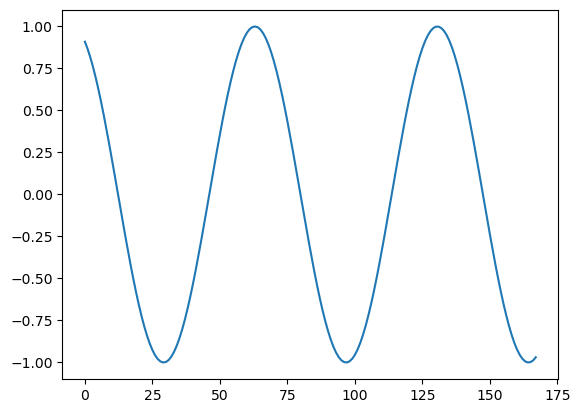

In [20]:
plt.plot(np.sin(2+freq*t))